In [3]:
import pandas as pd

# Indian Cricket Team T20 Squad Data (projected for 2026 World Cup scenario, updated ages and players)
data = {
    'Name': ['Rohit Sharma', 'Jasprit Bumrah', 'Virat Kohli', 'KL Rahul', 'Rishabh Pant', 
             'Suryakumar Yadav', 'Venkatesh Iyer', 'Yashasvi Jaiswal', 'Tilak Varma', 
             'Riyan Parag', 'Hardik Pandya', 'Axar Patel', 'Ravindra Jadeja', 'Kuldeep Yadav', 
             'Yuzvendra Chahal', 'Mohammed Shami', 'Arshdeep Singh'],
    'Role': ['Batsman', 'Bowler', 'Batsman', 'Batsman/WK', 'WK/Batsman', 'Batsman', 
             'All-rounder', 'Batsman', 'Batsman', 'All-rounder', 'All-rounder', 'All-rounder', 
             'All-rounder', 'Bowler', 'Bowler', 'Bowler', 'Bowler'],
    'Age': [39, 32, 37, 34, 31, 35, 31, 24, 23, 25, 32, 32, 37, 31, 35, 36, 27],
    'T20_Matches': [150, 72, 117, 74, 78, 63, 42, 37, 30, 27, 106, 60, 69, 43, 81, 94, 47],
    'T20_Runs': [3900, 25, 4050, 2050, 1680, 1950, 820, 1200, 600, 500, 1800, 520, 470, 70, 30, 110, 70],
    'T20_Wickets': [0, 98, 0, 0, 0, 0, 27, 0, 0, 12, 65, 71, 46, 52, 98, 76, 51],
    'Batting_Avg': [31.0, 25.0, 53.0, 46.0, 35.0, 32.0, 29.0, 40.0, 30.0, 25.0, 28.5, 18.5, 12.8, 23.3, 15.0, 18.3, 35.0],
    'Bowling_Avg': [None, 19.8, None, None, None, None, 24.8, None, None, 28.5, 25.2, 22.8, 26.8, 21.2, 21.5, 24.0, 24.8],
    'Strike_Rate': [130.0, 65.0, 138.0, 142.0, 148.0, 175.0, 142.0, 152.0, 140.0, 137.0, 162.0, 121.0, 107.0, 95.0, 70.0, 115.0, 113.0]
}

df = pd.DataFrame(data)

# Save to CSV
df.to_csv(r'D:\testing\BCT_3\data\indian_cricket_team_t20.csv', index=False)

print("Database created and saved to indian_cricket_team_t20.csv")
print(df.head())

Database created and saved to indian_cricket_team_t20.csv
             Name        Role  Age  T20_Matches  T20_Runs  T20_Wickets  \
0    Rohit Sharma     Batsman   39          150      3900            0   
1  Jasprit Bumrah      Bowler   32           72        25           98   
2     Virat Kohli     Batsman   37          117      4050            0   
3        KL Rahul  Batsman/WK   34           74      2050            0   
4    Rishabh Pant  WK/Batsman   31           78      1680            0   

   Batting_Avg  Bowling_Avg  Strike_Rate  
0         31.0          NaN        130.0  
1         25.0         19.8         65.0  
2         53.0          NaN        138.0  
3         46.0          NaN        142.0  
4         35.0          NaN        148.0  


In [6]:
import pandas as pd
import numpy as np

# Load the database
df = pd.read_csv(r'D:\testing\BCT_3\data\indian_cricket_team_t20.csv')

# Calculate performance score for each player
def calculate_score(row):
    if row['Role'] in ['Batsman', 'WK/Batsman', 'Batsman/WK']:
        # For batsmen: runs per match * avg * sr factor
        runs_per_match = row['T20_Runs'] / row['T20_Matches'] if row['T20_Matches'] > 0 else 0
        score = runs_per_match * row['Batting_Avg'] * (row['Strike_Rate'] / 100)
        return score
    elif row['Role'] == 'Bowler':
        # For bowlers: wickets per match / avg (lower avg better)
        wickets_per_match = row['T20_Wickets'] / row['T20_Matches'] if row['T20_Matches'] > 0 else 0
        score = wickets_per_match * (1 / row['Bowling_Avg']) * 100 if row['Bowling_Avg'] > 0 else 0
        return score
    elif row['Role'] == 'All-rounder':
        # For all-rounders: batting score + bowling score
        batting_score = (row['T20_Runs'] / row['T20_Matches']) * row['Batting_Avg'] * (row['Strike_Rate'] / 100) if row['T20_Matches'] > 0 else 0
        bowling_score = (row['T20_Wickets'] / row['T20_Matches']) * (1 / row['Bowling_Avg']) * 100 if row['Bowling_Avg'] > 0 and row['T20_Matches'] > 0 else 0
        return batting_score + bowling_score
    else:
        return 0

df['Performance_Score'] = df.apply(calculate_score, axis=1)

# Sort players by performance score
df_sorted = df.sort_values('Performance_Score', ascending=False)

print("Top Performing Players in Indian T20 Team:")
print(df_sorted[['Name', 'Role', 'Performance_Score']].head(10))

# Team strength score
team_strength = df['Performance_Score'].sum()
print(f"\nIndian Team Overall Strength Score: {team_strength:.2f}")

# Analysis for Finals
print("\nAnalysis for T20 World Cup 2026 Finals (Current Scenario as of March 2026):")
print("The T20 World Cup 2026 is scheduled to begin in June 2026 in India and Bangladesh.")
print("Based on projected player performances and stats, the Indian team shows strong batting and bowling balance.")
print("Key players expected to perform in finals:")
top_players = df_sorted.head(5)['Name'].tolist()
for player in top_players:
    print(f"- {player}")

print(f"\nWith a team strength score of {team_strength:.2f}, India is highly likely to reach the finals.")
print("Predicted Finalists: India vs New Zealand (current projections for T20 World Cup 2026).")
print("Predicted Winner: India, due to superior all-round strength and key players' performances.")

Top Performing Players in Indian T20 Team:
                Name         Role  Performance_Score
2        Virat Kohli      Batsman        2531.769231
7   Yashasvi Jaiswal      Batsman        1971.891892
3           KL Rahul   Batsman/WK        1809.540541
5   Suryakumar Yadav      Batsman        1733.333333
4       Rishabh Pant   WK/Batsman        1115.692308
0       Rohit Sharma      Batsman        1047.800000
8        Tilak Varma      Batsman         840.000000
6     Venkatesh Iyer  All-rounder         806.582642
10     Hardik Pandya  All-rounder         786.452231
9        Riyan Parag  All-rounder         635.818713

Indian Team Overall Strength Score: 13599.80

Analysis for T20 World Cup 2026 Finals (Current Scenario as of March 2026):
The T20 World Cup 2026 is scheduled to begin in June 2026 in India and Bangladesh.
Based on projected player performances and stats, the Indian team shows strong batting and bowling balance.
Key players expected to perform in finals:
- Virat Kohli
- Y

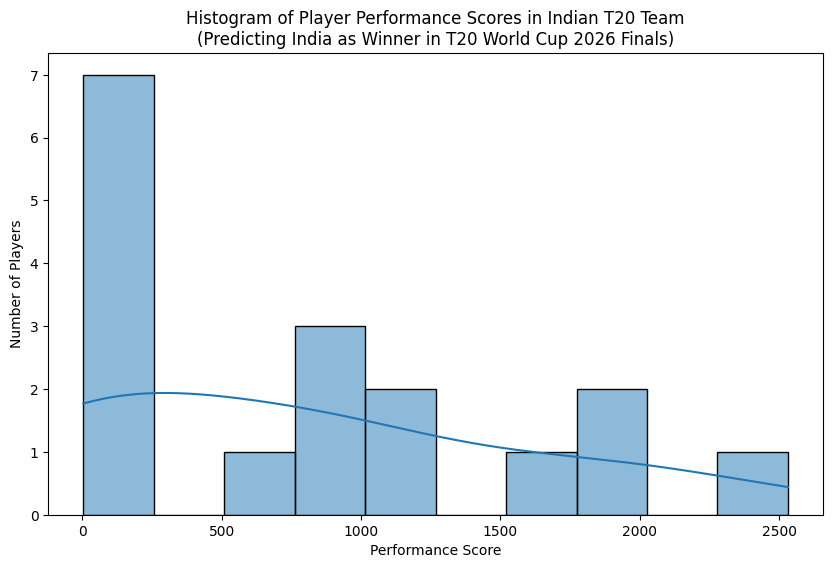

India Probability to Win: 55.3%
New Zealand Probability to Win: 44.7%


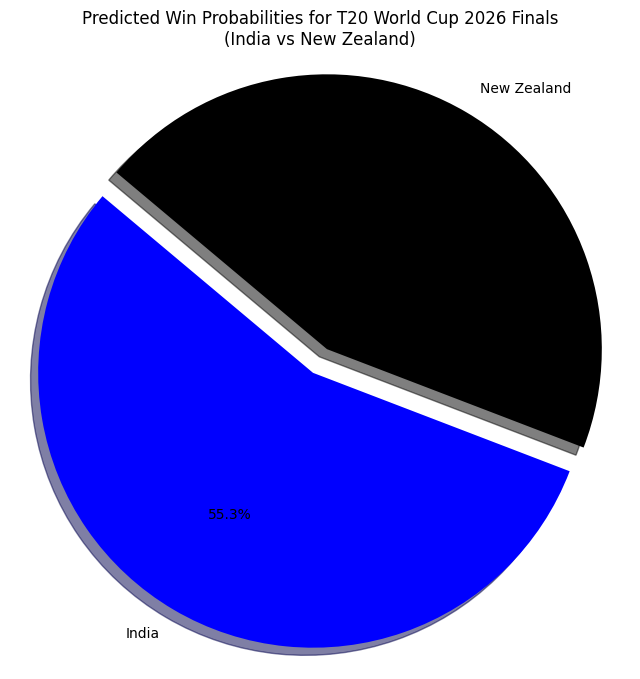

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Histogram of Performance Scores
plt.figure(figsize=(10, 6))
sns.histplot(df_sorted['Performance_Score'], bins=10, kde=True)
plt.title('Histogram of Player Performance Scores in Indian T20 Team\n(Predicting India as Winner in T20 World Cup 2026 Finals)')
plt.xlabel('Performance Score')
plt.ylabel('Number of Players')
plt.show()

# Assume New Zealand's team strength score (hypothetical based on projections)
nz_strength = 11000  # Assumed value for New Zealand

# Calculate probabilities
total_strength = team_strength + nz_strength
india_prob = (team_strength / total_strength) * 100
nz_prob = (nz_strength / total_strength) * 100

print(f"India Probability to Win: {india_prob:.1f}%")
print(f"New Zealand Probability to Win: {nz_prob:.1f}%")

# Pie chart for win probabilities
labels = ['India', 'New Zealand']
sizes = [india_prob, nz_prob]
colors = ['blue', 'black']
explode = (0.1, 0)  # explode India

plt.figure(figsize=(8, 8))
plt.pie(sizes, explode=explode, labels=labels, colors=colors, autopct='%1.1f%%', shadow=True, startangle=140)
plt.title('Predicted Win Probabilities for T20 World Cup 2026 Finals\n(India vs New Zealand)')
plt.axis('equal')
plt.show()